In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import os
import sys

import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

import warnings
warnings.filterwarnings('ignore')

from typing import Tuple, Dict, Any, List
from pathlib import Path
from IPython.display import display

from datetime import datetime, timedelta, time
import time

from tqdm.notebook import tqdm

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from prepare_data import load_and_process_data
from exchange_v2 import ExchangeSim, OpportunisticSpreadWidenMM, SWRParams, run_backtest, BTLogger

pd.options.display.float_format = '{:.6f}'.format
pd.set_option('display.max_columns', None)

In [6]:
# Symbol name
asset_name= 'HYPEUSDT'
quotes_df, trades_df, events_df = load_and_process_data(asset_name)

In [6]:
quotes_df.head()

,ts,exchange,symbol,timestamp,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,asks[2].price,asks[2].amount,bids[2].price,bids[2].amount,asks[3].price,asks[3].amount,bids[3].price,bids[3].amount,asks[4].price,asks[4].amount,bids[4].price,bids[4].amount,asks[5].price,asks[5].amount,bids[5].price,bids[5].amount,asks[6].price,asks[6].amount,bids[6].price,bids[6].amount,asks[7].price,asks[7].amount,bids[7].price,bids[7].amount,asks[8].price,asks[8].amount,bids[8].price,bids[8].amount,asks[9].price,asks[9].amount,bids[9].price,bids[9].amount,asks[10].price,asks[10].amount,bids[10].price,bids[10].amount,asks[11].price,asks[11].amount,bids[11].price,bids[11].amount,asks[12].price,asks[12].amount,bids[12].price,bids[12].amount,asks[13].price,asks[13].amount,bids[13].price,bids[13].amount,asks[14].price,asks[14].amount,bids[14].price,bids[14].amount,asks[15].price,asks[15].amount,bids[15].price,bids[15].amount,asks[16].price,asks[16].amount,bids[16].price,bids[16].amount,asks[17].price,asks[17].amount,bids[17].price,bids[17].amount,asks[18].price,asks[18].amount,bids[18].price,bids[18].amount,asks[19].price,asks[19].amount,bids[19].price,bids[19].amount,asks[20].price,asks[20].amount,bids[20].price,bids[20].amount,asks[21].price,asks[21].amount,bids[21].price,bids[21].amount,asks[22].price,asks[22].amount,bids[22].price,bids[22].amount,asks[23].price,asks[23].amount,bids[23].price,bids[23].amount,asks[24].price,asks[24].amount,bids[24].price,bids[24].amount,ts_us,date,best_ask,best_bid,mid,spread,spread_bps,spread_med_bps
0,2025-08-01 00:00:00.149,binance-futures,HYPEUSDT,1754006400149000,1754006401048006,40.824000,10.000000,40.823000,13.170000,40.827000,0.380000,40.822000,5.370000,40.830000,5.230000,40.821000,6.330000,40.832000,7.820000,40.820000,80.230000,40.833000,24.180000,40.819000,12.310000,40.834000,31.380000,40.818000,16.740000,40.835000,28.590000,40.817000,14.840000,40.836000,136.710000,40.816000,35.190000,40.837000,27.880000,40.815000,70.830000,40.838000,138.450000,40.814000,14.970000,40.840000,376.190000,40.813000,18.520000,40.841000,0.540000,40.812000,29.410000,40.842000,144.110000,40.811000,6.740000,40.844000,11822.840000,40.810000,57.810000,40.845000,1.420000,40.809000,6.330000,40.846000,52.910000,40.808000,0.630000,40.847000,80.840000,40.807000,0.560000,40.848000,130.080000,40.806000,2.580000,40.849000,2.990000,40.805000,111.230000,40.850000,188.470000,40.804000,703.620000,40.851000,208.490000,40.803000,375.790000,40.852000,144.250000,40.802000,75.280000,40.853000,15.750000,40.801000,15.330000,40.854000,86.610000,40.800000,75.080000,40.855000,39.370000,40.799000,38.360000,1754006400149000,2025-08-01,40.824000,40.823000,40.823500,0.001000,0.244957,0.244957
1,2025-08-01 00:00:01.777,binance-futures,HYPEUSDT,1754006401777000,1754006401780745,40.829000,0.130000,40.826000,10.100000,40.832000,2.590000,40.825000,1.870000,40.833000,24.180000,40.823000,53.970000,40.834000,5.370000,40.822000,5.370000,40.835000,2.580000,40.821000,6.330000,40.836000,39.100000,40.820000,77.570000,40.837000,27.880000,40.819000,12.310000,40.838000,92.220000,40.818000,6.950000,40.840000,331.410000,40.817000,14.840000,40.841000,0.540000,40.816000,35.190000,40.842000,70.790000,40.815000,70.830000,40.844000,11773.410000,40.814000,14.970000,40.845000,1.420000,40.813000,18.520000,40.846000,173.170000,40.812000,29.410000,40.847000,80.840000,40.811000,6.740000,40.848000,130.080000,40.810000,57.810000,40.849000,3.270000,40.809000,6.330000,40.850000,192.610000,40.808000,0.630000,40.851000,209.180000,40.807000,0.560000,40.852000,148.540000,40.806000,28.760000,40.853000,15.750000,40.805000,111.230000,40.854000,15.260000,40.804000,703.620000,40.855000,39.370000,40.803000,375.790000,40.856000,125.100000,40.802000,75.280000,40.857000,644.230000,40.801000,15.330000,1754006401777000,2025-08-01,40.829000,40.826000,40.827500,0.003000,0.734799,0.734799
2,2025-08-01 00:00:01.830,binance-futu

In [7]:
# After implementing log
params = SWRParams()

sim = ExchangeSim(
    asset_name="HYPE",
    tick_size=0.001,
    maker_fee=0.0000,
    taker_fee=0.0005,
    latency_us=5_000,
    depth_levels=5,
)
logger = BTLogger()

strategy = OpportunisticSpreadWidenMM(params, logger=logger)
eq = run_backtest(events_df, quotes_df, trades_df, sim, strategy, logger)
log_df = logger.to_df()

In [8]:
# Basic information
display(log_df["reason"].value_counts())
display(log_df["action"].value_counts())
display(log_df.query("action == 'FILL'")["fill_source"].value_counts())

reason
tox_fail                    7550
exit_suppressed_min_hold    2611
enter_regime                1400
exit_regime                 1329
inv_gate                      81
tight_spread                  68
price_change                  36
ttl                           10
Name: count, dtype: int64

action
CANCEL_ALL    7606
REGIME        5229
PLACE          114
GATE            81
CANCEL          55
FILL            44
Name: count, dtype: int64

fill_source
trade_through    26
quote_cross      18
Name: count, dtype: int64

In [9]:
# Cross check fills
fills_df = pd.DataFrame([f.__dict__ for f in sim.fills])
print("fills:", len(fills_df), "final pos:", sim.pos, "final cash:", sim.cash)

fills: 44 final pos: 11.400000000000002 final cash: -466.46001


In [10]:
# Cross check fills
fills_df = pd.DataFrame([f.__dict__ for f in sim.fills])
print("fills:", len(fills_df), "final pos:", sim.pos, "final cash:", sim.cash)

fills: 44 final pos: 11.400000000000002 final cash: -466.46001


In [11]:
# Fill rate
orders_df = pd.DataFrame(
    {oid: vars(o) for oid, o in sim.orders.items()}
).T

n_orders = orders_df.shape[0]
n_filled_orders = fills_df["order_id"].nunique()

fill_rate = n_filled_orders / n_orders
print("Fill rate:", fill_rate)

Fill rate: 0.23684210526315788


In [12]:
fills_df = fills_df.sort_values("ts_us")

fills_df["signed_qty"] = np.where(
    fills_df["side"] == "buy",
    fills_df["qty"],
    -fills_df["qty"]
)

fills_df["signed_notional"] = np.where(
    fills_df["side"] == "buy",
    -fills_df["price"] * fills_df["qty"],
    fills_df["price"] * fills_df["qty"]
)

fills_df["pnl_contrib"] = fills_df["signed_notional"] - fills_df["fee"]
fills_df["cum_pnl"] = fills_df["pnl_contrib"].cumsum()
win_rate = (fills_df["pnl_contrib"] > 0).mean()
print(win_rate)

0.36363636363636365


In [13]:
# Log analysis
ld = log_df.copy().sort_values(["ts_us","event_i"]).reset_index(drop=True)

# mark regime flips
reg = ld[(ld.action=="REGIME") & (ld.reason.isin(["enter_regime","exit_regime"]))][
    ["ts_us","event_i","reason","spread_bps","med_bps","pos"]
].copy()

# pair enter->exit
enters = reg[reg.reason=="enter_regime"].reset_index(drop=True)
exits  = reg[reg.reason=="exit_regime"].reset_index(drop=True)

# if counts mismatch (end of day), align by index min len
m = min(len(enters), len(exits))
episodes = pd.DataFrame({
    "enter_ts_us": enters.loc[:m-1, "ts_us"].values,
    "enter_event_i": enters.loc[:m-1, "event_i"].values,
    "enter_spread_bps": enters.loc[:m-1, "spread_bps"].values,
    "enter_med_bps": enters.loc[:m-1, "med_bps"].values,
    "enter_pos": enters.loc[:m-1, "pos"].values,
    "exit_ts_us": exits.loc[:m-1, "ts_us"].values,
    "exit_event_i": exits.loc[:m-1, "event_i"].values,
})

episodes["dur_ms"] = (episodes["exit_ts_us"] - episodes["enter_ts_us"]) / 1000.0

In [14]:
# 1) regime entries
regimes = log_df.query("action=='REGIME' and reason=='enter_regime'").copy()

# 2) one PLACE per event_i? (in your system you might PLACE 2 sides same event_i)
# Keep all places, but also create an "any place" indicator per event_i.
places = log_df.query("action=='PLACE'").copy()

# 3) For "why skipped", grab the FIRST blocking reason after enter within the same regime window.
# We'll approximate: look at logs on the same event_i (immediate) OR next few events.
# (This is usually enough because your tox_fail/tight_spread triggers right away.)
block_actions = ["CANCEL_ALL", "GATE", "CANCEL"]
blocks = log_df[log_df["action"].isin(block_actions)].copy()

# Helper: for each enter event_i, find earliest blocking row within a small lookahead window.
LOOKAHEAD_EVENTS = 50  # tweak if needed

# Keep just the minimal columns we care about
reg0 = regimes[["ts_us","ts","event_i","spread_bps","med_bps","pos",
               "enter_thr_bps","enter_excess_bps"]].copy()
for c in ["enter_thr_bps","enter_excess_bps"]:
    if c not in reg0.columns:
        reg0[c] = np.nan

# Index blocks by event_i for fast lookup
blocks_small = blocks[["ts_us","ts","event_i","action","reason","tox_count","tox_total","tox_net","gated_side"]].copy()
for c in ["tox_count","tox_total","tox_net","gated_side"]:
    if c not in blocks_small.columns:
        blocks_small[c] = np.nan

# Build mapping from enter row -> first block in [event_i, event_i+LOOKAHEAD]
blocks_sorted = blocks_small.sort_values(["event_i","ts_us"], kind="mergesort")

def first_block_after(ei: int):
    m = blocks_sorted[(blocks_sorted.event_i >= ei) & (blocks_sorted.event_i <= ei + LOOKAHEAD_EVENTS)]
    if len(m) == 0:
        return None
    return m.iloc[0]

first_blocks = []
for ei in reg0["event_i"].to_numpy():
    fb = first_block_after(int(ei))
    first_blocks.append(fb.to_dict() if fb is not None else {})

fb_df = pd.DataFrame(first_blocks)
fb_df = fb_df.add_prefix("block_")

# Merge in "did we place at least one order?"
placed_any = places.groupby("event_i").size().rename("n_places").reset_index()
reg = reg0.merge(placed_any, on="event_i", how="left")
reg["n_places"] = reg["n_places"].fillna(0).astype(int)
reg["did_trade"] = reg["n_places"] > 0

# attach first block info (approx reason for skip / behavior right after enter)
reg = pd.concat([reg.reset_index(drop=True), fb_df.reset_index(drop=True)], axis=1)

# A nicer "skip_reason" field
reg["skip_reason"] = np.where(
    reg["did_trade"], 
    "traded",
    reg.get("block_reason", pd.Series([np.nan]*len(reg))).fillna("no_block_found")
)

# Show a compact view
cols = [
    "ts","event_i","spread_bps","med_bps","enter_thr_bps","enter_excess_bps","pos",
    "did_trade","n_places","skip_reason",
    "block_action","block_reason","block_tox_count","block_tox_total","block_tox_net","block_gated_side"
]
cols = [c for c in cols if c in reg.columns]
reg[cols].head(5)

,ts,event_i,spread_bps,med_bps,enter_thr_bps,enter_excess_bps,pos,did_trade,n_places,skip_reason,block_action,block_reason,block_tox_count,block_tox_total,block_tox_net,block_gated_side
0,2025-08-01 00:01:02.405000+00:00,4187,1.956756,0.244565,1.711952,0.244804,0.000000,True,2,traded,CANCEL_ALL,tox_fail,NaN,NaN,NaN,NaN
1,2025-08-01 00:02:26.214000+00:00,7967,1.957043,0.244717,1.713020,0.244023,3.000000,False,0,tox_fail,CANCEL_ALL,tox_fail,NaN,NaN,NaN,NaN
2,2025-08-01 00:04:06.733000+00:00,10455,1.956373,0.244508,1.711554,0.244819,3.000000,False,0,tox_fail,CANCEL_ALL,tox_fail,NaN,NaN,NaN,NaN
3,2025-08-01 00:05:11.592000+00:00,13138,2.447381,0.244807,1.713649,0.733732,3.000000,False,0,tox_fail,CANCEL_ALL,tox_fail,NaN,NaN,NaN,NaN
4,2025-08-01 00:06:35.148000+00:00,16318,2.198420,0.244352,1.710467,0.487953,3.000000,False,0,tox_fail,CANCEL_ALL,tox_fail,NaN,NaN,NaN,NaN


In [15]:
tox = log_df.query("action=='CANCEL_ALL' and reason=='tox_fail'")
tox[["tox_count","tox_total","tox_net"]].describe()

,tox_count,tox_total,tox_net
count,3769.000000,3769.000000,3769.000000
mean,54.826479,714.261648,-220.996983
std,92.210303,2090.321591,2059.643581
min,1.000000,5.230000,-36518.590000
25%,19.000000,81.760000,-203.270000
50%,30.000000,201.670000,-32.660000
75%,52.000000,519.930000,136.050000
max,1345.000000,39642.850000,13815.150000


In [16]:
def summarize_episode(ep):
    sub = ld[(ld.ts_us>=ep.enter_ts_us) & (ld.ts_us<=ep.exit_ts_us)]
    out = {
        "places": int((sub.action=="PLACE").sum()),
        "cancels": int((sub.action=="CANCEL").sum()),
        "fills": int((sub.action=="FILL").sum()),
        "cancel_all": int((sub.action=="CANCEL_ALL").sum()),
        "gate": int((sub.action=="GATE").sum()),
    }
    # most common cancel_all reason
    if out["cancel_all"]>0:
        out["top_block"] = sub[sub.action=="CANCEL_ALL"]["reason"].value_counts().idxmax()
    else:
        out["top_block"] = None
    return pd.Series(out)

ep_stats = episodes.apply(summarize_episode, axis=1)
episodes2 = pd.concat([episodes, ep_stats], axis=1)

episodes2["fill_rate_ep"] = episodes2["fills"] / episodes2["places"].replace(0,np.nan)
episodes2.sort_values(["fills","places"], ascending=False).head(5)

,enter_ts_us,enter_event_i,enter_spread_bps,enter_med_bps,enter_pos,exit_ts_us,exit_event_i,dur_ms,places,cancels,fills,cancel_all,gate,top_block,fill_rate_ep
50,1754009163423000,99999,1.721276,0.245872,9.000000,1754009163599000,100012,176.000000,2.000000,2.000000,5.000000,2.000000,0.000000,tox_fail,2.500000
803,1754066460367000,1983556,2.047712,0.255941,12.140000,1754066460532000,1983565,165.000000,2.000000,1.000000,4.000000,4.000000,0.000000,tox_fail,2.000000
0,1754006462405000,4187,1.956756,0.244565,0.000000,1754006462561000,4201,156.000000,2.000000,2.000000,3.000000,4.000000,0.000000,tox_fail,1.500000
1063,1754077893053000,2479880,1.875092,0.267834,14.260000,1754077893206000,2479913,153.000000,2.000000,1.000000,3.000000,4.000000,0.000000,tox_fail,1.500000
108,1754010591828000,166954,2.196488,0.244078,17.990000,1754010591983000,166973,155.000000,1.000000,1.000000,3.000000,4.000000,1.000000,tox_fail,3.000000


In [17]:
episodes2[episodes2.dur_ms > 100][["dur_ms","places","fills","top_block"]].describe()

,dur_ms,places,fills
count,1309.000000,1309.000000,1309.000000
mean,156.742552,0.087089,0.033613
std,5.055974,0.445905,0.279964
min,152.000000,0.000000,0.000000
25%,154.000000,0.000000,0.000000
50%,155.000000,0.000000,0.000000
75%,158.000000,0.000000,0.000000
max,222.000000,5.000000,5.000000


In [18]:
reg = ld[(ld.action=="REGIME") & (ld.reason.isin(["enter_regime","exit_regime"]))][["ts_us","reason"]]
reg["dt_ms"] = reg.ts_us.diff() / 1000.0
reg["flip"] = reg.reason

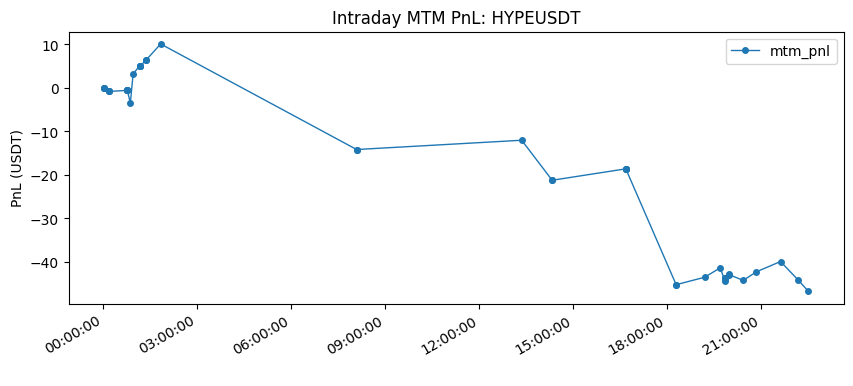

In [19]:
# Result analysis
quotes = quotes_df[["ts_us", "mid"]].copy()

fills = log_df.query("action=='FILL'").copy()
fills = fills.sort_values("ts_us")

fills = pd.merge_asof(
    fills,
    quotes[["ts_us", "mid"]],
    on="ts_us",
    direction="backward",
    allow_exact_matches=True
)

fills["signed_qty"] = np.where(
    fills.side == "buy",
    fills.qty,
    -fills.qty
)

fills["trade_cash"] = -fills.signed_qty * fills.price
fills["net_cash"] = fills.trade_cash - fills.fee

fills["cum_cash"] = fills.net_cash.cumsum()
fills["position"] = fills.signed_qty.cumsum()

fills["mtm_pnl"] = fills.cum_cash + fills.position * fills.mid

fills["fee_bps"] = fills.fee / (fills.qty * fills.price) * 1e4
#fills["fee_bps"].describe()

pnl_curve = fills[["ts_us", "mtm_pnl", "mid"]].copy()
pnl_curve["ts"] = pd.to_datetime(pnl_curve.ts_us, unit="us")

ax = pnl_curve.plot(
    x="ts", 
    y="mtm_pnl", 
    figsize=(10,4), 
    title="Intraday MTM PnL: HYPEUSDT",
    marker='o',      # 'o' for circles, 's' for squares, 'x' for crosses
    markersize=4,    # Adjust the size here
    linewidth=1      # Optional: thinning the line helps markers stand out
)

ax.set_ylabel("PnL (USDT)")
ax.set_xlabel(" ")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gcf().autofmt_xdate()
plt.show()

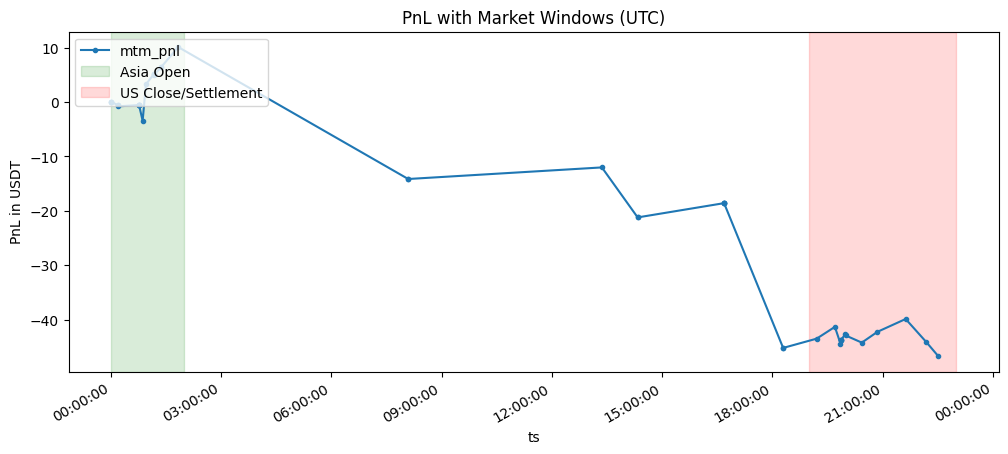

In [20]:
 # 1. Create the base plot
ax = pnl_curve.plot(x="ts", y="mtm_pnl", figsize=(12, 5), 
                    title="PnL with Market Windows (UTC)", marker='o', markersize=3)

# 2. Define our UTC windows (adjust hours as needed)
# Window 1: 00:00 - 02:00 (Asia Open)
# Window 2: 19:00 - 23:00 (US Close/Late Session)
start_date = pnl_curve['ts'].min().date()

# Shading for Asia Open (00:00 - 02:00 UTC)
ax.axvspan(pd.Timestamp(f"{start_date} 00:00:00"), 
           pd.Timestamp(f"{start_date} 02:00:00"), 
           color='green', alpha=0.15, label='Asia Open')

# Shading for US Late/Close (19:00 - 23:00 UTC)
ax.axvspan(pd.Timestamp(f"{start_date} 19:00:00"), 
           pd.Timestamp(f"{start_date} 23:00:00"), 
           color='red', alpha=0.15, label='US Close/Settlement')

# 3. Formatting
ax.set_ylabel("PnL in USDT")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.legend(loc='upper left')
plt.gcf().autofmt_xdate()
plt.show()

In [27]:
n_place = (log_df.action == "PLACE").sum()
n_fill = (log_df.action == "FILL").sum()

fill_stats = {
    "signal_entered": len(reg),
    "traded": reg.did_trade.sum(),
    "orders_placed": n_place,
    "fills": n_fill,
    "fill_rate": n_fill / max(n_place, 1),
    "avg_trade_hold_ms": episodes.dur_ms.mean(),
    "median_trade_hold_ms": episodes.dur_ms.median(),
}

pd.DataFrame(fill_stats, index=["value"]).T

,value
signal_entered,1309.000000
traded,58.000000
orders_placed,114.000000
fills,44.000000
fill_rate,0.385965
avg_trade_hold_ms,156.742552
median_trade_hold_ms,155.000000


In [21]:
def episode_pnl(ep):
    m = (fills.ts_us >= ep.enter_ts_us) & (fills.ts_us <= ep.exit_ts_us)
    if not m.any():
        return 0.0

    mtm_start = fills.loc[m, "mtm_pnl"].iloc[0]
    mtm_end   = fills.loc[m, "mtm_pnl"].iloc[-1]
    return mtm_end - mtm_start

episodes["episode_pnl"] = episodes.apply(episode_pnl, axis=1)
episodes["episode_pnl"].describe()

count   1309.000000
mean      -0.000024
std        0.001590
min       -0.039865
25%        0.000000
50%        0.000000
75%        0.000000
max        0.010045
Name: episode_pnl, dtype: float64

In [22]:
quotes_mid = quotes_df[["ts_us"]].copy()
if "mid" in quotes_df.columns:
    quotes_mid["mid"] = quotes_df["mid"].astype(float)
else:
    quotes_mid["mid"] = (quotes_df["best_bid"].astype(float) + quotes_df["best_ask"].astype(float)) / 2

quotes_mid = quotes_mid.sort_values("ts_us").reset_index(drop=True)

fills = fills.sort_values("ts_us").reset_index(drop=True)

horizons_ms = [50, 150, 300]  # add 300 if you want: [10, 50, 150, 300]

for h in horizons_ms:
    # mid at t + h
    tmp = fills[["ts_us"]].copy()
    tmp["ts_us_h"] = tmp["ts_us"] + h * 1000  # ms -> us

    tmp = pd.merge_asof(
        tmp.sort_values("ts_us_h"),
        quotes_mid.rename(columns={"ts_us": "ts_us_q", "mid": f"mid_{h}ms"}).sort_values("ts_us_q"),
        left_on="ts_us_h",
        right_on="ts_us_q",
        direction="backward",
        allow_exact_matches=True
    ).sort_index()

    fills[f"mid_{h}ms"] = tmp[f"mid_{h}ms"].values

    # adverse selection: signed move against our fill
    # buy: mid goes down => negative; so use (mid_future - fill_price)
    # sell: mid goes up => negative; so use (fill_price - mid_future)
    fills[f"as_{h}ms"] = np.where(
        fills["side"].eq("buy"),
        fills[f"mid_{h}ms"] - fills["price"],
        fills["price"] - fills[f"mid_{h}ms"]
    )

# Summary table
as_cols = [f"as_{h}ms" for h in horizons_ms]
fills[as_cols].describe()

,as_50ms,as_150ms,as_300ms
count,44.000000,44.000000,44.000000
mean,-0.001693,-0.002602,-0.003773
std,0.001654,0.004340,0.007101
min,-0.004500,-0.010000,-0.018500
25%,-0.002375,-0.005500,-0.008500
50%,-0.001500,-0.002000,-0.002000
75%,-0.000500,-0.000500,0.001750
max,0.002500,0.008500,0.009500


In [23]:
pnl_curve.tail()

,ts_us,mtm_pnl,mid,ts
39,1754079949486000,-44.230585,37.240500,2025-08-01 20:25:49.486
40,1754081481452000,-42.247195,37.567500,2025-08-01 20:51:21.452
41,1754084244238000,-39.890495,37.827500,2025-08-01 21:37:24.238
42,1754086285246000,-44.171010,37.122500,2025-08-01 22:11:25.246
43,1754087435426000,-46.717710,36.819500,2025-08-01 22:30:35.426


In [24]:
fills['mtm_pnl'].tail()

39   -44.230585
40   -42.247195
41   -39.890495
42   -44.171010
43   -46.717710
Name: mtm_pnl, dtype: float64

In [25]:
episodes.head()

,enter_ts_us,enter_event_i,enter_spread_bps,enter_med_bps,enter_pos,exit_ts_us,exit_event_i,dur_ms,episode_pnl
0,1754006462405000,4187,1.956756,0.244565,0.000000,1754006462561000,4201,156.000000,0.008610
1,1754006546214000,7967,1.957043,0.244717,3.000000,1754006546368000,7999,154.000000,0.000000
2,1754006646733000,10455,1.956373,0.244508,3.000000,1754006646888000,10458,155.000000,0.000000
3,1754006711592000,13138,2.447381,0.244807,3.000000,1754006711747000,13147,155.000000,0.000000
4,1754006795148000,16318,2.198420,0.244352,3.000000,1754006795301000,16333,153.000000,0.000000


In [26]:
episodes.tail()

,enter_ts_us,enter_event_i,enter_spread_bps,enter_med_bps,enter_pos,exit_ts_us,exit_event_i,dur_ms,episode_pnl
1304,1754091860015000,2996341,2.133845,0.266656,11.400000,1754091860168000,2996346,153.000000,0.000000
1305,1754091937592000,2998913,6.685833,0.267326,11.400000,1754091937749000,2998925,157.000000,0.000000
1306,1754092358346000,3008860,4.272363,0.266969,11.400000,1754092358500000,3008871,154.000000,0.000000
1307,1754092507627000,3012181,2.134757,0.266805,11.400000,1754092507781000,3012185,154.000000,0.000000
1308,1754092650117000,3016840,1.861430,0.265883,11.400000,1754092650274000,3016843,157.000000,0.000000


In [27]:
episodes['episode_pnl'].sum()

np.float64(-0.03149499999998184)

In [44]:
fills[['ts_us', 'mtm_pnl']]

,ts_us,mtm_pnl
0,1754006462416000,-0.000673
1,1754006462416000,-0.001346
2,1754006462416000,-0.015529
3,1754007113595000,-0.661158
4,1754007113595000,-0.663931
5,1754007121224000,-0.884815
6,1754009163487000,-0.642041
7,1754009163487000,-0.644801
8,1754009163487000,-0.645646
9,1754009163487000,-0.646378
